Q1 · Class Distribution


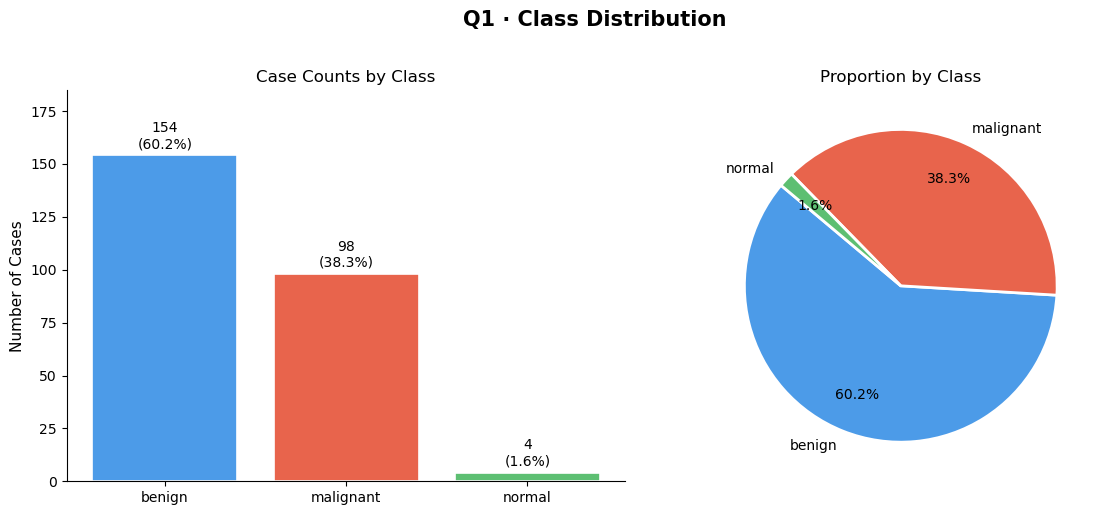

  Saved → eda_figures/q1_class_distribution.png
Classification
benign       154
malignant     98
normal         4

Q2 · Image–Mask Pairs
benign: 154 valid masked cases, showing 2
malignant: 98 valid masked cases, showing 2
normal: 0 valid masked cases, showing 0


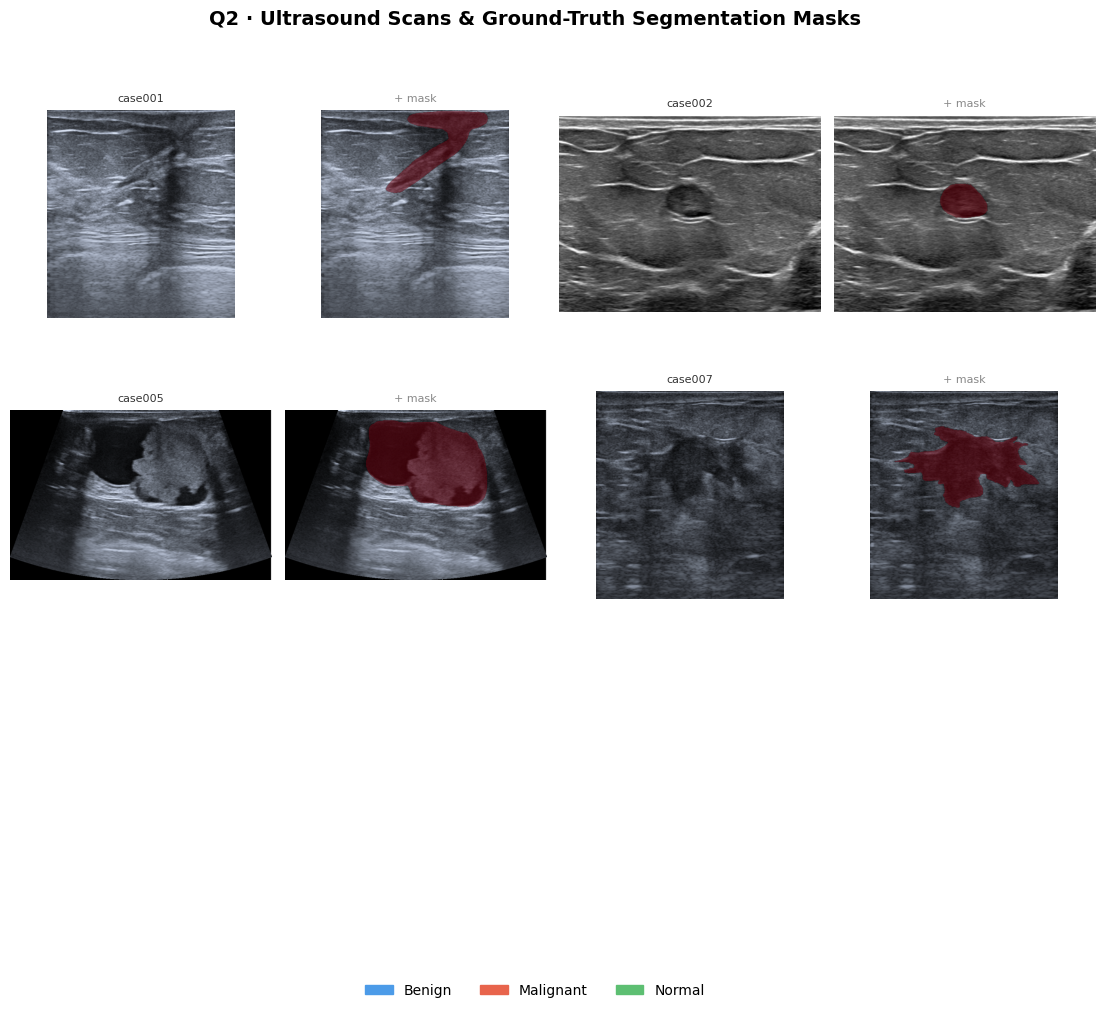

  Saved → eda_figures/q2_image_mask_pairs.png

Q3 · Lesion Pixel Area


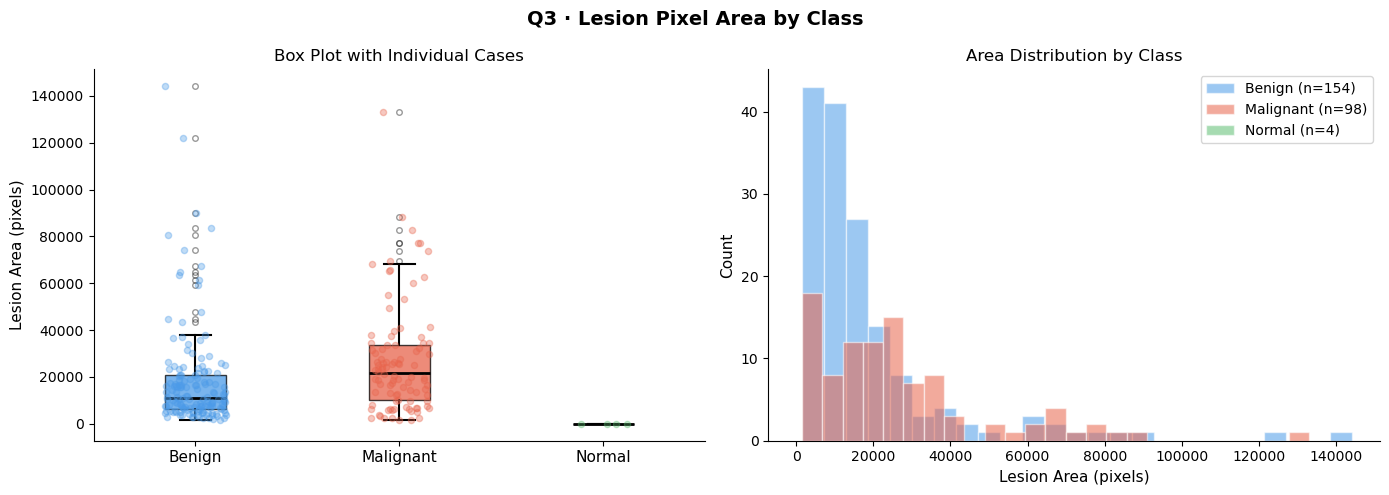

  Saved → eda_figures/q3_lesion_area.png

Lesion area summary (pixels):
                count          mean           std     min   median       max
Classification                                                              
benign          154.0  18253.551948  21360.218379  1515.0  11170.0  144084.0
malignant        98.0  26881.183673  23162.812319  1518.0  21662.0  132942.0
normal            4.0      0.000000      0.000000     0.0      0.0       0.0

Q4 · Pixel Intensity Distribution


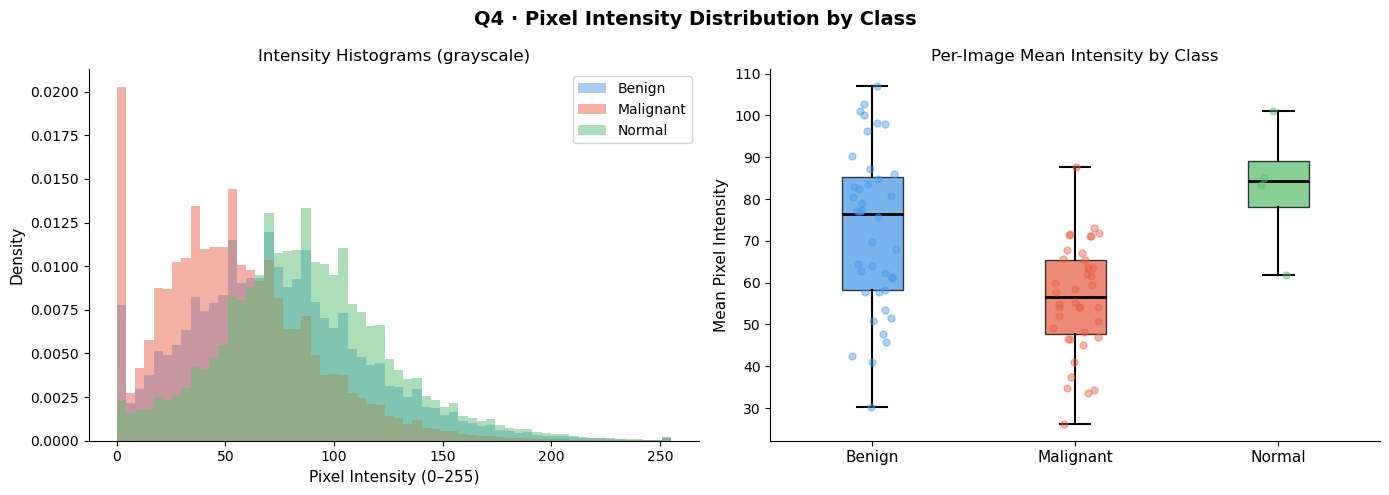

  Saved → eda_figures/q4_pixel_intensity.png

Mean pixel intensity summary:
           count       mean        std        min     median         max
Class                                                                   
benign      40.0  72.492143  19.303017  30.286975  76.485914  107.007176
malignant   40.0  56.322252  13.040903  26.212404  56.517904   87.732363
normal       4.0  82.861334  16.121529  61.842636  84.253697  101.095306

All figures saved to: /Users/emilymoore/anaconda_projects/80675dbd-9d8d-4372-8fc2-61022be1e0eb/eda_figures


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from PIL import Image
 
# ─────────────────────────────────────────────────────────────────────────────
# CONFIG  ← update these paths to match your local folder structure
# ─────────────────────────────────────────────────────────────────────────────
IMAGE_DIR = "/Users/emilymoore/Downloads/DS 4002 Project 3/Breast Lesions USG Images"    # folder with case001.png …
MASK_DIR  = "/Users/emilymoore/Downloads/DS 4002 Project 3/Breast Lesions USG Masks"     # folder with tumor mask images
EXCEL_PATH = "/Users/emilymoore/Downloads/DS 4002 Project 3/Breast-Lesions-USG-clinical-data.xlsx"
 
OUTPUT_DIR = "eda_figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
COLORS = {"benign": "#4C9BE8", "malignant": "#E8644C", "normal": "#5DBF72"}
plt.rcParams.update({"font.family": "DejaVu Sans", "axes.spines.top": False,
                     "axes.spines.right": False})
 
# ─────────────────────────────────────────────────────────────────────────────
# Load metadata
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_excel(EXCEL_PATH)
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
classes   = ["benign", "malignant", "normal"]
 
 
# ─────────────────────────────────────────────────────────────────────────────
# Q1 — Class distribution
# ─────────────────────────────────────────────────────────────────────────────
def plot_class_distribution(df):
    counts = df["Classification"].value_counts().reindex(classes)
    pcts   = counts / counts.sum() * 100
 
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Q1 · Class Distribution", fontsize=15, fontweight="bold", y=1.02)
 
    # Bar chart
    bars = axes[0].bar(classes, counts.values,
                       color=[COLORS[c] for c in classes], edgecolor="white", linewidth=1.2)
    for bar, n, p in zip(bars, counts.values, pcts.values):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                     f"{n}\n({p:.1f}%)", ha="center", va="bottom", fontsize=10)
    axes[0].set_ylabel("Number of Cases", fontsize=11)
    axes[0].set_title("Case Counts by Class", fontsize=12)
    axes[0].set_ylim(0, counts.max() * 1.2)
 
    # Pie chart
    wedges, texts, autotexts = axes[1].pie(
        counts.values, labels=classes, autopct="%1.1f%%",
        colors=[COLORS[c] for c in classes],
        startangle=140, pctdistance=0.75,
        wedgeprops={"edgecolor": "white", "linewidth": 2}
    )
    for t in autotexts:
        t.set_fontsize(10)
    axes[1].set_title("Proportion by Class", fontsize=12)
 
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, "q1_class_distribution.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {path}")
    print(counts.to_string())
 
 
# ─────────────────────────────────────────────────────────────────────────────
# Q2 — Paired image + mask gallery (2 examples per class)
# ─────────────────────────────────────────────────────────────────────────────
def plot_image_mask_pairs(df, image_dir, mask_dir, n_per_class=2):
    fig = plt.figure(figsize=(14, 10))
    fig.suptitle("Q2 · Ultrasound Scans & Ground-Truth Segmentation Masks",
                 fontsize=14, fontweight="bold")

    n_cols = n_per_class * 2
    n_rows = len(classes)
    gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, hspace=0.35, wspace=0.05)

    for row_i, cls in enumerate(classes):
        subset = df[df["Classification"] == cls].copy()

        # Robust NaN filter — catches both float NaN and string "nan"
        subset = subset[
            subset["Mask_tumor_filename"].apply(
                lambda x: isinstance(x, str) and x.strip().lower() not in ("nan", "", "none")
            )
        ]

        # Also verify the mask file actually exists on disk
        subset = subset[
            subset["Mask_tumor_filename"].apply(
                lambda x: os.path.exists(os.path.join(mask_dir, x))
            )
        ]

        samples = subset.head(n_per_class)
        print(f"{cls}: {len(subset)} valid masked cases, showing {len(samples)}")
 
    for row_i, cls in enumerate(classes):
        subset = df[df["Classification"] == cls].dropna(subset=["Mask_tumor_filename"])
        subset = subset[subset["Mask_tumor_filename"].astype(str).str.strip() != "nan"]
        samples = subset.head(n_per_class)
 
        for col_i, (_, row) in enumerate(samples.iterrows()):
            img_path  = os.path.join(image_dir, row["Image_filename"])
            mask_path = os.path.join(mask_dir,  row["Mask_tumor_filename"])
 
            img  = np.array(Image.open(img_path).convert("RGB"))
            mask = np.array(Image.open(mask_path).convert("L"))
 
            # Image panel
            ax_img  = fig.add_subplot(gs[row_i, col_i * 2])
            ax_img.imshow(img, cmap="gray")
            ax_img.axis("off")
            if col_i == 0:
                ax_img.set_ylabel(cls.capitalize(), fontsize=11,
                                  color=COLORS[cls], fontweight="bold")
            title = row["Image_filename"].replace(".png", "")
            ax_img.set_title(title, fontsize=8, color="#333333")
 
            # Overlay mask
            ax_msk  = fig.add_subplot(gs[row_i, col_i * 2 + 1])
            ax_msk.imshow(img, cmap="gray")
            masked = np.ma.masked_where(mask == 0, mask)
            ax_msk.imshow(masked, cmap="Reds", alpha=0.55, vmin=0, vmax=255)
            ax_msk.axis("off")
            ax_msk.set_title("+ mask", fontsize=8, color="#888888")
 
    legend_patches = [Patch(color=COLORS[c], label=c.capitalize()) for c in classes]
    fig.legend(handles=legend_patches, loc="lower center", ncol=3,
               fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.02))
 
    path = os.path.join(OUTPUT_DIR, "q2_image_mask_pairs.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {path}")
 
 
# ─────────────────────────────────────────────────────────────────────────────
# Q3 — Lesion pixel area by class
# ─────────────────────────────────────────────────────────────────────────────
def compute_mask_areas(df, mask_dir):
    areas = []
    for _, row in df.iterrows():
        fname = str(row["Mask_tumor_filename"]).strip()
        if fname in ("nan", ""):
            areas.append(0)
            continue
        path = os.path.join(mask_dir, fname)
        if not os.path.exists(path):
            areas.append(0)
            continue
        mask = np.array(Image.open(path).convert("L"))
        areas.append(int((mask > 127).sum()))
    df = df.copy()
    df["lesion_area_px"] = areas
    return df
 
 
def plot_lesion_area(df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Q3 · Lesion Pixel Area by Class", fontsize=14, fontweight="bold")
 
    # Box + strip plot (manual)
    data_by_cls = [df[df["Classification"] == c]["lesion_area_px"].values for c in classes]
    bp = axes[0].boxplot(data_by_cls, patch_artist=True, notch=False,
                         medianprops={"color": "black", "linewidth": 2},
                         whiskerprops={"linewidth": 1.5},
                         capprops={"linewidth": 1.5},
                         flierprops={"marker": "o", "markersize": 4, "alpha": 0.4})
    for patch, cls in zip(bp["boxes"], classes):
        patch.set_facecolor(COLORS[cls])
        patch.set_alpha(0.75)
    for i, (cls, vals) in enumerate(zip(classes, data_by_cls)):
        jitter = np.random.uniform(-0.15, 0.15, len(vals))
        axes[0].scatter(np.full(len(vals), i + 1) + jitter, vals,
                        color=COLORS[cls], alpha=0.35, s=20, zorder=3)
    axes[0].set_xticks([1, 2, 3])
    axes[0].set_xticklabels([c.capitalize() for c in classes], fontsize=11)
    axes[0].set_ylabel("Lesion Area (pixels)", fontsize=11)
    axes[0].set_title("Box Plot with Individual Cases", fontsize=12)
 
    # Histogram per class
    for cls in classes:
        vals = df[df["Classification"] == cls]["lesion_area_px"].values
        axes[1].hist(vals, bins=25, alpha=0.55, color=COLORS[cls],
                     label=f"{cls.capitalize()} (n={len(vals)})", edgecolor="white")
    axes[1].set_xlabel("Lesion Area (pixels)", fontsize=11)
    axes[1].set_ylabel("Count", fontsize=11)
    axes[1].set_title("Area Distribution by Class", fontsize=12)
    axes[1].legend(fontsize=10)
 
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, "q3_lesion_area.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {path}")
 
    # Summary stats
    print("\nLesion area summary (pixels):")
    print(df.groupby("Classification")["lesion_area_px"]
          .describe()[["count", "mean", "std", "min", "50%", "max"]]
          .rename(columns={"50%": "median"}).to_string())
 
 
# ─────────────────────────────────────────────────────────────────────────────
# Q4 — Pixel intensity distribution by class
# ─────────────────────────────────────────────────────────────────────────────
def plot_pixel_intensity(df, image_dir, sample_n=40):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Q4 · Pixel Intensity Distribution by Class", fontsize=14, fontweight="bold")
 
    all_means, all_stds, all_cls = [], [], []
 
    for cls in classes:
        subset = df[df["Classification"] == cls].head(sample_n)
        intensities = []
        for _, row in subset.iterrows():
            path = os.path.join(image_dir, row["Image_filename"])
            if not os.path.exists(path):
                continue
            img = np.array(Image.open(path).convert("L")).flatten()
            intensities.append(img)
            all_means.append(img.mean())
            all_stds.append(img.std())
            all_cls.append(cls)
 
        if intensities:
            combined = np.concatenate(intensities)
            axes[0].hist(combined, bins=60, alpha=0.50, color=COLORS[cls],
                         label=f"{cls.capitalize()}", density=True, edgecolor="none")
 
    axes[0].set_xlabel("Pixel Intensity (0–255)", fontsize=11)
    axes[0].set_ylabel("Density", fontsize=11)
    axes[0].set_title("Intensity Histograms (grayscale)", fontsize=12)
    axes[0].legend(fontsize=10)
 
    # Mean intensity per image by class — box plot
    mean_df = pd.DataFrame({"Class": all_cls, "Mean Intensity": all_means})
    data_by_cls = [mean_df[mean_df["Class"] == c]["Mean Intensity"].values for c in classes]
    bp = axes[1].boxplot(data_by_cls, patch_artist=True,
                         medianprops={"color": "black", "linewidth": 2},
                         whiskerprops={"linewidth": 1.5},
                         capprops={"linewidth": 1.5},
                         flierprops={"marker": "o", "markersize": 4, "alpha": 0.4})
    for patch, cls in zip(bp["boxes"], classes):
        patch.set_facecolor(COLORS[cls])
        patch.set_alpha(0.75)
    for i, (cls, vals) in enumerate(zip(classes, data_by_cls)):
        jitter = np.random.uniform(-0.12, 0.12, len(vals))
        axes[1].scatter(np.full(len(vals), i + 1) + jitter, vals,
                        color=COLORS[cls], alpha=0.45, s=25, zorder=3)
    axes[1].set_xticks([1, 2, 3])
    axes[1].set_xticklabels([c.capitalize() for c in classes], fontsize=11)
    axes[1].set_ylabel("Mean Pixel Intensity", fontsize=11)
    axes[1].set_title("Per-Image Mean Intensity by Class", fontsize=12)
 
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, "q4_pixel_intensity.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {path}")
 
    print("\nMean pixel intensity summary:")
    print(mean_df.groupby("Class")["Mean Intensity"]
          .describe()[["count", "mean", "std", "min", "50%", "max"]]
          .rename(columns={"50%": "median"}).to_string())
 
 
# ─────────────────────────────────────────────────────────────────────────────
# Run all
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 60)
    print("Q1 · Class Distribution")
    print("=" * 60)
    plot_class_distribution(df)
 
    print("\n" + "=" * 60)
    print("Q2 · Image–Mask Pairs")
    print("=" * 60)
    plot_image_mask_pairs(df, IMAGE_DIR, MASK_DIR, n_per_class=2)
 
    print("\n" + "=" * 60)
    print("Q3 · Lesion Pixel Area")
    print("=" * 60)
    df = compute_mask_areas(df, MASK_DIR)
    plot_lesion_area(df)
 
    print("\n" + "=" * 60)
    print("Q4 · Pixel Intensity Distribution")
    print("=" * 60)
    plot_pixel_intensity(df, IMAGE_DIR, sample_n=40)
 
    print("\nAll figures saved to:", os.path.abspath(OUTPUT_DIR))